In [1]:
# Multi-Class Classification Example
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target  # labels: 0,1,2

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



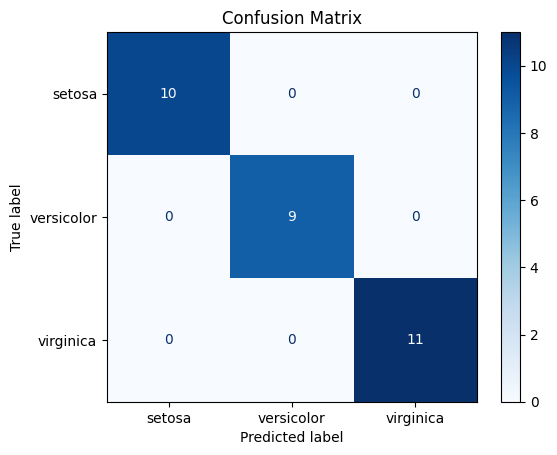

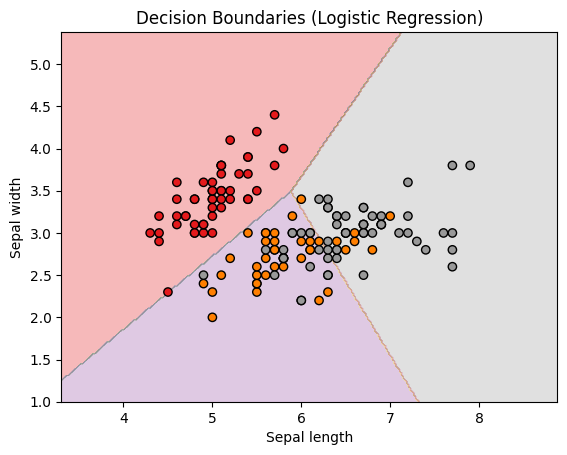

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# --- Existing Code ---
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target  # labels: 0,1,2

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# --- Visualization ---

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.show()

# 2. Decision Boundaries (using first 2 features: sepal length & sepal width)
X_plot = X[:, :2]  # take only first 2 features for visualization
X_train_plot, X_test_plot, y_train_plot, y_test_plot = train_test_split(X_plot, y, test_size=0.2, random_state=42)

clf2 = LogisticRegression(max_iter=200)
clf2.fit(X_train_plot, y_train_plot)

# Create meshgrid
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, edgecolor="k", cmap=plt.cm.Set1)
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Decision Boundaries (Logistic Regression)")
plt.show()


In [2]:
# Multi-Label Classification Example
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create synthetic dataset
X, y = make_multilabel_classification(n_samples=1000, n_features=20, n_classes=5, n_labels=2, random_state=42)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Multi-label classifier (One-vs-Rest strategy)
clf = MultiOutputClassifier(LogisticRegression(max_iter=200))
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
print("Sample Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Sample Accuracy: 0.425
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.64      0.70        66
           1       0.80      0.74      0.77       102
           2       0.87      0.78      0.82       101
           3       0.74      0.70      0.72        71
           4       0.67      0.49      0.56        37

   micro avg       0.79      0.70      0.74       377
   macro avg       0.77      0.67      0.71       377
weighted avg       0.79      0.70      0.74       377
 samples avg       0.77      0.71      0.70       377



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Sample Accuracy: 0.425
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.64      0.70        66
           1       0.80      0.74      0.77       102
           2       0.87      0.78      0.82       101
           3       0.74      0.70      0.72        71
           4       0.67      0.49      0.56        37

   micro avg       0.79      0.70      0.74       377
   macro avg       0.77      0.67      0.71       377
weighted avg       0.79      0.70      0.74       377
 samples avg       0.77      0.71      0.70       377



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


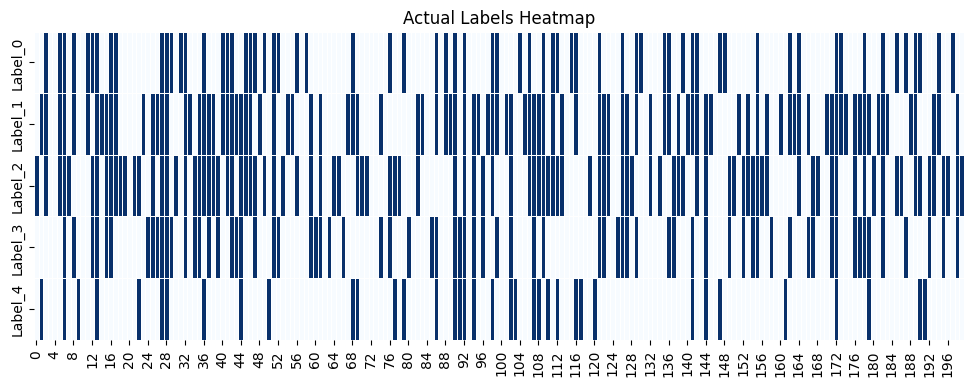

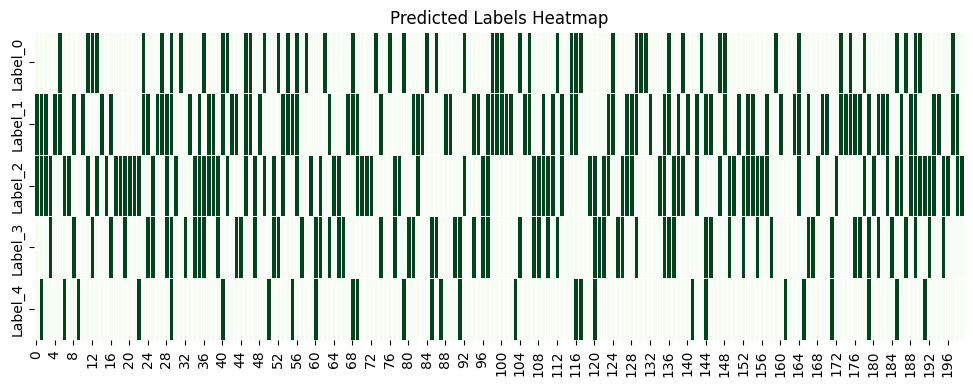

Sample Predictions vs Actual:
             Actual        Predicted
0  [0, 0, 1, 0, 0]  [0, 1, 1, 0, 0]
1  [0, 1, 0, 0, 1]  [0, 1, 1, 0, 1]
2  [1, 1, 1, 0, 0]  [0, 1, 1, 0, 0]
3  [0, 0, 0, 0, 0]  [0, 0, 1, 1, 0]
4  [0, 0, 0, 0, 0]  [0, 1, 0, 0, 0]
5  [1, 1, 1, 0, 0]  [1, 1, 0, 0, 0]
6  [1, 1, 1, 1, 1]  [0, 0, 1, 0, 1]
7  [0, 0, 1, 0, 0]  [0, 0, 1, 0, 0]
8  [1, 1, 0, 1, 0]  [0, 1, 0, 1, 0]
9  [0, 0, 0, 0, 1]  [0, 0, 0, 0, 1]


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- Existing Code ---
X, y = make_multilabel_classification(
    n_samples=1000, n_features=20, n_classes=5, n_labels=2, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = MultiOutputClassifier(LogisticRegression(max_iter=200))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluation
print("Sample Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- Visualization ---

# 1. Label distribution heatmap (Actual vs Predicted)
df_actual = pd.DataFrame(y_test, columns=[f"Label_{i}" for i in range(y.shape[1])])
df_pred = pd.DataFrame(y_pred, columns=[f"Label_{i}" for i in range(y.shape[1])])

plt.figure(figsize=(12,4))
sns.heatmap(df_actual.T, cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Actual Labels Heatmap")
plt.show()

plt.figure(figsize=(12,4))
sns.heatmap(df_pred.T, cmap="Greens", cbar=False, linewidths=0.5)
plt.title("Predicted Labels Heatmap")
plt.show()

# 2. Sample comparison of first 10 instances
comparison = pd.DataFrame({
    'Actual': df_actual.iloc[:10].values.tolist(),
    'Predicted': df_pred.iloc[:10].values.tolist()
})
print("Sample Predictions vs Actual:\n", comparison)


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==== Dataset (Iris) ====
iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)   # long for CrossEntropyLoss
y_test = torch.tensor(y_test, dtype=torch.long)

# ==== Model ====
class MultiClassNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MultiClassNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))  # logits

model = MultiClassNN(input_dim=4, hidden_dim=16, output_dim=3)

# ==== Loss & Optimizer ====
criterion = nn.CrossEntropyLoss()  # multi-class
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==== Training ====
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
#====Evaluation====

with torch.no_grad():
    outputs = model(X_test)
    _, preds = torch.max(outputs, 1)
    acc = (preds == y_test).float().mean()
    print("Test Accuracy:", acc.item())


Epoch 20, Loss: 0.4669
Epoch 40, Loss: 0.2885
Epoch 60, Loss: 0.1677
Epoch 80, Loss: 0.0994
Epoch 100, Loss: 0.0741
Test Accuracy: 0.9666666388511658


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==== Dataset (Synthetic) ====
X, y = make_multilabel_classification(n_samples=1000, n_features=20, n_classes=5, n_labels=2, random_state=42)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)  # float for BCE
y_test = torch.tensor(y_test, dtype=torch.float32)

# ==== Model ====
class MultiLabelNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MultiLabelNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))  # logits

model = MultiLabelNN(input_dim=20, hidden_dim=32, output_dim=5)

# ==== Loss & Optimizer ====
criterion = nn.BCEWithLogitsLoss()  # multi-label
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==== Training ====
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ==== Evaluation ====
with torch.no_grad():
    outputs = model(X_test)
    preds = (torch.sigmoid(outputs) > 0.5).float()  # thresholding
    acc = (preds == y_test).float().mean()
    print("Test Accuracy:", acc.item())


Epoch 10, Loss: 0.5143
Epoch 20, Loss: 0.4138
Epoch 30, Loss: 0.3762
Epoch 40, Loss: 0.3500
Epoch 50, Loss: 0.3318
Test Accuracy: 0.8339999914169312


In [5]:
# Multi-Label k-NN (Synthetic Dataset)
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import make_multilabel_classification
from sklearn.multioutput import MultiOutputClassifier

# ==== Step 1: Generate dataset ====
X, y = make_multilabel_classification(n_samples=1000, n_features=20,
                                      n_classes=5, n_labels=2, random_state=42)

# ==== Step 2: Train-Test Split ====
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ==== Step 3: Feature Scaling ====
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==== Step 4: Multi-label k-NN Model ====
k = 5
base_knn = KNeighborsClassifier(n_neighbors=k)
multi_knn = MultiOutputClassifier(base_knn)
multi_knn.fit(X_train, y_train)

# ==== Step 5: Predictions ====
y_pred = multi_knn.predict(X_test)

# ==== Step 6: Evaluation ====
print("\nMulti-Label k-NN (Synthetic Dataset)")
print("Sample Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Multi-Label k-NN (Synthetic Dataset)
Sample Accuracy: 0.44

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.59      0.64       106
           1       0.77      0.86      0.81       160
           2       0.85      0.77      0.81       151
           3       0.68      0.68      0.68       111
           4       0.62      0.25      0.36        51

   micro avg       0.76      0.70      0.73       579
   macro avg       0.72      0.63      0.66       579
weighted avg       0.75      0.70      0.72       579
 samples avg       0.77      0.70      0.70       579



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
